In [1]:
# Core
import os
import importlib
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model / Feature selection / Scaling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC, LinearSVC

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Saving Model
import joblib


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Saving Model
import joblib

from scipy.stats import loguniform, randint


In [5]:
svm = joblib.load("svm.pkl")
svm_irus = joblib.load("svm_irus.pkl")
svm_irus_Norway = joblib.load("svm_irus_Norway.pkl")
svm_irus_rfe = joblib.load("svm_irus_rfe.pkl")
svm_irus_rfe_Norway = joblib.load("svm_irus_rfe_Norway.pkl")
svm_Norway = joblib.load("svm_Norway.pkl")
svm_rfe = joblib.load("svm_rfe.pkl")
svm_rfe_Norway = joblib.load("svm_rfe_Norway.pkl")
svm_smote = joblib.load("svm_smote.pkl")
svm_smote_Norway = joblib.load("svm_smote_Norway.pkl")
svm_smote_rfe = joblib.load("svm_smote_rfe.pkl.pkl")  # note the double .pkl
svm_smote_rfe_Norway = joblib.load("svm_smote_rfe_Norway.pkl")

svm_purified = joblib.load("Purified/svm.pkl")
svm_irus_purified = joblib.load("Purified/svm_irus.pkl")
svm_irus_Norway_purified = joblib.load("Purified/svm_irus_Norway.pkl")
svm_irus_rfe_purified = joblib.load("Purified/svm_irus_rfe.pkl")
svm_irus_rfe_Norway_purified = joblib.load("Purified/svm_irus_rfe_Norway.pkl")
svm_Norway_purified = joblib.load("Purified/svm_Norway.pkl")
svm_rfe_purified = joblib.load("Purified/svm_rfe.pkl")
svm_rfe_Norway_purified = joblib.load("Purified/svm_rfe_Norway.pkl")
svm_smote_purified = joblib.load("Purified/svm_smote.pkl")
svm_smote_Norway_purified = joblib.load("Purified/svm_smote_Norway.pkl")
svm_smote_rfe_purified = joblib.load("Purified/svm_smote_rfe.pkl")
svm_smote_rfe_Norway_purified = joblib.load("Purified/svm_smote_rfe_Norway.pkl")

In [7]:
X_train = pd.read_csv('../Datasets/X_train.csv')
X_test  = pd.read_csv('../Datasets/X_test.csv')

y_train = pd.read_csv('../Datasets/Y_train.csv').squeeze("columns")  
y_test  = pd.read_csv('../Datasets/Y_test.csv').squeeze("columns")    # -> Series

X_train_Norway = pd.read_csv('../Datasets/X_train_Norway.csv')
X_test_Norway  = pd.read_csv('../Datasets/X_test_Norway.csv')

y_train_Norway = pd.read_csv('../Datasets/Y_train_Norway.csv').squeeze("columns")  
y_test_Norway  = pd.read_csv('../Datasets/Y_test_Norway.csv').squeeze("columns")    # -> Series

X_train_purified = pd.read_csv('../Datasets/X_train_purified.csv')
X_test_purified  = pd.read_csv('../Datasets/X_test_purified.csv')  
y_train_purified = pd.read_csv('../Datasets/Y_train_purified.csv').squeeze("columns")
y_test_purified  = pd.read_csv('../Datasets/Y_test_purified.csv').squeeze("columns")    # -> Series

X_train_Norway_purified = pd.read_csv('../Datasets/X_train_Norway_purified.csv')
X_test_Norway_purified  = pd.read_csv('../Datasets/X_test_Norway_purified.csv')
y_train_Norway_purified = pd.read_csv('../Datasets/Y_train_Norway_purified.csv').squeeze("columns")
y_test_Norway_purified  = pd.read_csv('../Datasets/Y_test_Norway_purified.csv').squeeze("columns")    # -> Series

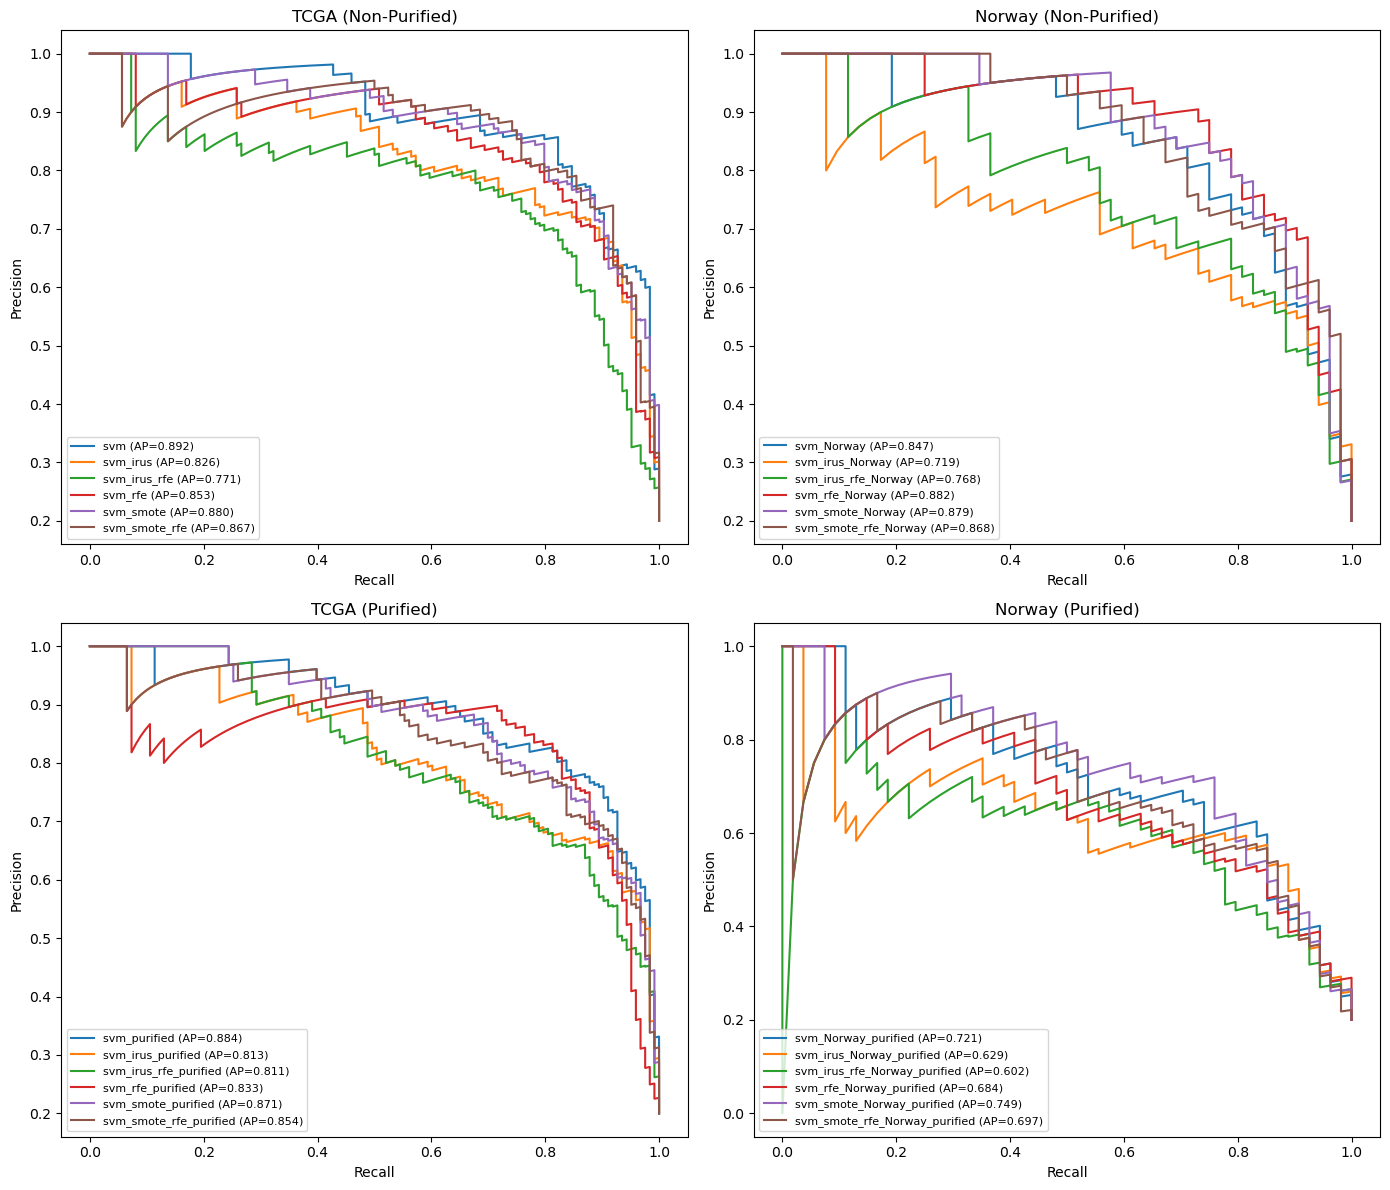

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

def get_feature_names(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return None

def align_X(model, X):
    cols = get_feature_names(model)
    if cols is None:
        return X
    missing = [c for c in cols if c not in X.columns]
    if missing:
        raise ValueError(f"Missing {len(missing)} columns for model: {missing[:5]}...")
    return X.loc[:, cols]

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise ValueError("Model has no predict_proba or decision_function.")

def get_classes(model):
    if hasattr(model, "classes_"):
        return model.classes_
    if hasattr(model, "steps"):
        for _, step in reversed(model.steps):
            if hasattr(step, "classes_"):
                return step.classes_
    raise ValueError("Model has no classes_.")

def plot_pr_curves(ax, model_entries, X_te, y_te, title):
    for name, model in model_entries:
        X_aligned = align_X(model, X_te)
        scores = get_scores(model, X_aligned)

        classes = get_classes(model)
        y_bin = label_binarize(y_te, classes=classes)

        if scores.ndim == 1:
            scores = scores.reshape(-1, 1)
            y_bin = y_bin.reshape(-1, 1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), scores.ravel())
        ap = average_precision_score(y_bin, scores, average="micro")
        ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8, loc="lower left")

# Only include models that exist
def pick_models(names):
    return [(n, globals()[n]) for n in names if n in globals()]

tcga_models = pick_models([
    "svm", "svm_irus", "svm_irus_rfe", "svm_rfe", "svm_smote", "svm_smote_rfe"
])

norway_models = pick_models([
    "svm_Norway", "svm_irus_Norway", "svm_irus_rfe_Norway",
    "svm_rfe_Norway", "svm_smote_Norway", "svm_smote_rfe_Norway"
])

tcga_p_models = pick_models([
    "svm_purified", "svm_irus_purified", "svm_irus_rfe_purified",
    "svm_rfe_purified", "svm_smote_purified", "svm_smote_rfe_purified"
])

norway_p_models = pick_models([
    "svm_Norway_purified", "svm_irus_Norway_purified", "svm_irus_rfe_Norway_purified",
    "svm_rfe_Norway_purified", "svm_smote_Norway_purified", "svm_smote_rfe_Norway_purified"
])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plot_pr_curves(axes[0, 0], tcga_models, X_test, y_test, "TCGA (Non‑Purified)")
plot_pr_curves(axes[0, 1], norway_models, X_test_Norway, y_test_Norway, "Norway (Non‑Purified)")
plot_pr_curves(axes[1, 0], tcga_p_models, X_test_purified, y_test_purified, "TCGA (Purified)")
plot_pr_curves(axes[1, 1], norway_p_models, X_test_Norway_purified, y_test_Norway_purified, "Norway (Purified)")

plt.tight_layout()
